In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def rbf_kernel(x1, x2, length_scale=1.0, sigma_f=1.0):
    y = x1.reshape(-1, 1)-x2.reshape(1,-1)
    return sigma_f**2 * np.exp(-0.5 / length_scale**2 * np.square(y))

# Gaussian Process Regression class
class GaussianProcess:
    def __init__(self, kernel, noise=1e-3):
        self.kernel = kernel
        self.noise = noise


    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        self.K = self.kernel(X_train, X_train) + self.noise * np.eye(len(X_train))
        self.K_inv = np.linalg.inv(self.K)


    def predict(self, X_s):
        K_s = self.kernel(self.X_train, X_s)
        K_ss = self.kernel(X_s, X_s)

        mu_s = K_s.T.dot(self.K_inv).dot(self.y_train)
        cov_s = K_ss - K_s.T.dot(self.K_inv).dot(K_s)
        return mu_s, cov_s
    

# class GaussianProcess:
#     def __init__(self, kernel, noise=1e-3):
#         self.kernel = kernel
#         self.noise = noise

#     def fit(self, X_train, y_train):
#         self.X_train = X_train
#         self.y_train = y_train
#         K = self.kernel(X_train, X_train) + self.noise * np.eye(len(X_train))
#         self.L = np.linalg.cholesky(K)

#     def predict(self, X_s):
#         K_s = self.kernel(self.X_train, X_s)
#         K_ss = self.kernel(X_s, X_s)

#         v = np.linalg.solve(self.L, self.y_train) # First solve L v = y
#         alpha = np.linalg.solve(self.L.T, v) # Then solve L^T alpha = v
#         mu_s = K_s.T.dot(alpha)

#         v = np.linalg.solve(self.L, K_s) # Solve for L\K_s
#         cov_s = K_ss - v.T.dot(v)

#         return mu_s, cov_s

In [21]:
# Training data (noisy observations)
X_train = np.array([[-4], [-3], [-2], [-1], [1]]).astype(float)
y_train = np.sin(X_train) + 0.1 * np.random.randn(*X_train.shape)

# Test points
X_test = np.linspace(-5, 5, 100).reshape(-1, 1)

# Fit GP and predict
gp = GaussianProcess(rbf_kernel)
gp.fit(X_train, y_train)
mu_s, cov_s = gp.predict(X_test)
std_s = np.sqrt(np.diag(cov_s))

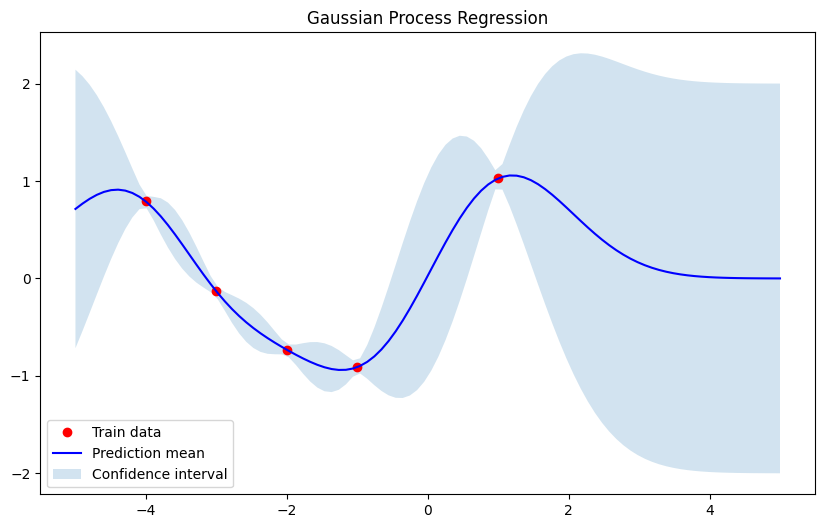

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(X_train, y_train, 'ro', label='Train data')
plt.plot(X_test, mu_s, 'b', label='Prediction mean')
plt.fill_between(X_test.ravel(),
mu_s.ravel() - 2 * std_s,
mu_s.ravel() + 2 * std_s,
alpha=0.2, label='Confidence interval')
plt.legend()
plt.title("Gaussian Process Regression")
plt.savefig("gaussian_result.png", dpi=300, bbox_inches='tight')
plt.show()